## CNN CIA Test 1
### Instructions
**Marks: 15**
- Identify and correct the errors without completely rewriting the program.
- Execute the corrected program successfully.

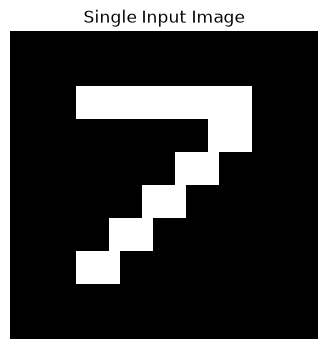

Input shape: (28, 28, 1)
Minimum: 0.0
Maximum: 1.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 8)        │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,480 (21.41 KB)

 Trainable params: 5,480 (21.41 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step



Final feature representation shape: (1, 32)
Forward pass completed successfully.
First convolution output shape: (1, 24, 24, 32)


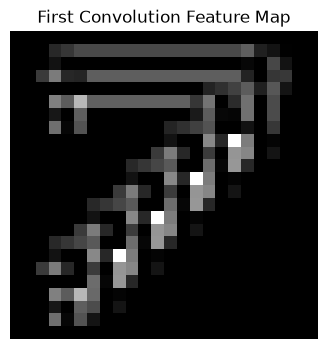

In [1]:
# BUG : so here in import statment tensorflow was there but as tf was missing so fix is , 
# FIX: to add as tf.
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# CNN DEBUGGING TEST
# ============================================================

# Create one local 28 x 28 grayscale image
image = np.zeros((28, 28, 1), dtype=np.float32)

image[5:8, 6:22] = 1.0
image[8:11, 18:22] = 1.0
image[11:14, 15:19] = 1.0
image[14:17, 12:16] = 1.0
image[17:20, 9:13] = 1.0
image[20:23, 6:10] = 1.0

# Display the input image
# BUG : plt.imshow()where image is (28, 28, 1) because imshow needs a plain 2D array for a grayscale image, not 3D
# FIX: added [:, :, 0] to drop the extra channel dimension
plt.figure(figsize=(4, 4))
plt.imshow(image[:, :, 0], cmap="gray")
plt.title("Single Input Image")
plt.axis("off")
plt.show()

print("Input shape:", image.shape)
print("Minimum:", image.min())
print("Maximum:", image.max())

# BUG:image = image * 255.0 labeled as normalization. The image already is in normalised form and if we multiply it with 255 it will not be normalised image so fix is 

# FIX: to removed that line completely.

# BUG:image.reshape(28, 28, 1) but 
#reshape does NOT add a batch dimension still only 3 numbers = 3D so we need to add a channel also like a chnnel number because keras needs 4 input and last one is channel
# FIX: add channel to (1, 28, 28, 1) .
# Add batch dimension
image = image.reshape(1, 28, 28, 1)

# ============================================================
# CNN MODEL
# ============================================================

model = tf.keras.Sequential([
    # BUG:input_shape=(28, 28) was written inside the first Conv2D layer,
    # and it was missing the channel dimension. Also, newer Keras needs an
    # explicit Input layer for some features (like getting a layer's output) to work.
    # FIX: added a separate "tf.keras.Input(shape=(28, 28, 1))" as the first layer,
    # with the correct 3-value shape including the channel.
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(5, 5),
        # BUG was: activation="sigmoid". Sigmoid is a weak choice for
        # convolution layers (causes vanishing gradients). FIX: changed to "relu",
        # the standard activation used for conv layers.
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=(3, 3)
    ),

    tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(3, 3),
        # Same fix as above: sigmoid -> relu.
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # BUG was: "tf.keras.layers.Flatten" with no "()" and no comma after it.
    # Without "()" it refers to the class itself, not a layer, and the missing
    # comma caused a syntax error. FIX: added "()" and a trailing comma.
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        32,
        activation="sigmoid"
    )
])

model.summary()

# ============================================================
# FORWARD PASS
# ============================================================

output = model.predict(image)

print("\nFinal feature representation shape:", output.shape)
print("Forward pass completed successfully.")

# ============================================================
# FIRST CONVOLUTION FEATURE MAP
# ============================================================

# BUG : used "tf.keras.Model(inputs=model.input, outputs=model.layers[2].output)".
# Two problems: 1 - model.layers[2] is the SECOND Conv2D layer, not the first
# 2 -  model.input raised an error in this Keras version because the model had not been called on data yet in a way that keeps that info available.
# FIX: simplified to directly call the first layer on the image:
# model.layers[0](image) -- now it correctly points at the FIRST convolution layer.

feature_maps = model.layers[0](image)

print("First convolution output shape:", feature_maps.shape)

plt.figure(figsize=(5, 4))
plt.imshow(feature_maps[0, :, :, 0], cmap="gray")
plt.title("First Convolution Feature Map")
plt.axis("off")
plt.show()
